# Final Evaluation Summary — Cultural Atlas Project

This notebook is the **final scientific summary of the frozen evaluation stage**.

Its purpose is not to rerun modelling. Instead, it:

- loads the evaluation outputs already produced by the project;
- checks that the expected result files are present;
- presents the main quantitative and qualitative evidence in one place;
- explains **what each metric evaluates**;
- records **what can and cannot be concluded** from each result;
- provides a compact reference for writing the final **Results, Discussion, Limitations and Conclusion** sections of the report.

> **Recommended use:** run this notebook from the project root, then keep it open while writing the report.

The notebook separates three questions:

1. **Semantic quality** — are nearby items meaningfully related in the representation?
2. **Projection fidelity** — does the 2D atlas preserve local relationships from the higher-dimensional representation?
3. **Cross-domain behaviour** — do the General Semantic and Feel approaches produce the kinds of cross-domain relationships they were designed to produce?

## 0. Evaluation philosophy

This project is not a conventional classification problem with a single ground-truth label and one final accuracy score.

An atlas can be useful while still being imperfect in several different ways. Evaluation therefore needs to be **multi-dimensional**:

| Evaluation question | Typical evidence |
|---|---|
| Are semantically similar items located near one another? | neighbourhood/category/tag coherence, lift |
| Does the 2D projection preserve the original representation? | trustworthiness |
| Are clusters interpretable? | cluster composition, representative items, qualitative inspection |
| Does a cross-domain method actually mix domains? | cross-domain neighbour share |
| Do Method A and Method B behave differently in the intended way? | matched-population comparison |
| Are Feel dimensions meaningful and non-redundant? | correlation, extremes, domain summaries |
| Are discovered analogies interpretable to a human? | qualitative neighbour examples |

**No individual metric validates the entire atlas.** The final argument is built from converging quantitative and qualitative evidence.

In [1]:
from pathlib import Path
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

# ---------------------------------------------------------
# PROJECT PATHS
# ---------------------------------------------------------

PROJECT_ROOT = Path("../")

# Change this single path if your evaluation folder lives elsewhere.
EVALUATION_ROOT = PROJECT_ROOT / "data" / "processed" / "evaluation"

print("Project root:", PROJECT_ROOT.resolve())
print("Evaluation root:", EVALUATION_ROOT.resolve())

Project root: C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe
Evaluation root: C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\evaluation


### Path note

The default evaluation path is:

```text
data/processed/evaluation/
```

If your actual folder has another name, change only `EVALUATION_ROOT` in the previous cell. Everything else uses paths relative to it.

In [2]:
FILES = {
    # Root-level fusion-weight experiments
    "movie_fusion_weights":
        EVALUATION_ROOT / "movie_fusion_weight_evaluation.csv",
    "music_fusion_weights":
        EVALUATION_ROOT / "music_fusion_weight_evaluation.csv",
    "restaurant_fusion_weights":
        EVALUATION_ROOT / "restaurant_fusion_weight_evaluation.csv",

    # Mono-domain evaluation
    "mono_atlas_summary":
        EVALUATION_ROOT / "mono_domain" / "mono_atlas_summary.csv",
    "mono_projection_fidelity":
        EVALUATION_ROOT / "mono_domain" / "mono_projection_fidelity.csv",
    "movies_semantic_coherence":
        EVALUATION_ROOT / "mono_domain" / "movies_semantic_coherence.csv",
    "music_semantic_coherence":
        EVALUATION_ROOT / "mono_domain" / "music_semantic_coherence.csv",
    "restaurants_semantic_coherence":
        EVALUATION_ROOT / "mono_domain" / "restaurants_semantic_coherence.csv",

    # Atlas comparison
    "atlas_metrics_summary":
        EVALUATION_ROOT / "atlas_comparison" / "atlas_metrics_summary.csv",
    "cross_domain_comparison":
        EVALUATION_ROOT / "atlas_comparison" / "cross_domain_comparison.csv",

    "composition_movies_music":
        EVALUATION_ROOT / "atlas_comparison" / "cluster_composition" / "movies_music.csv",
    "composition_movies_music_feel":
        EVALUATION_ROOT / "atlas_comparison" / "cluster_composition" / "movies_music_feel.csv",
    "composition_movies_music_restaurants":
        EVALUATION_ROOT / "atlas_comparison" / "cluster_composition" / "movies_music_restaurants.csv",
    "composition_movies_music_restaurants_feel":
        EVALUATION_ROOT / "atlas_comparison" / "cluster_composition" / "movies_music_restaurants_feel.csv",

    # Matched cross-domain evaluation
    "matched_atlas_metrics":
        EVALUATION_ROOT / "cross_domain_matched" / "matched_atlas_metrics.csv",
    "matched_method_comparison":
        EVALUATION_ROOT / "cross_domain_matched" / "matched_method_comparison.csv",
    "matched_population_summary":
        EVALUATION_ROOT / "cross_domain_matched" / "matched_population_summary.csv",

    "matched_composition_mm_a":
        EVALUATION_ROOT / "cross_domain_matched" / "cluster_composition" / "movies_music_method_a.csv",
    "matched_composition_mm_b":
        EVALUATION_ROOT / "cross_domain_matched" / "cluster_composition" / "movies_music_method_b.csv",
    "matched_composition_mmr_a":
        EVALUATION_ROOT / "cross_domain_matched" / "cluster_composition" / "movies_music_restaurants_method_a.csv",
    "matched_composition_mmr_b":
        EVALUATION_ROOT / "cross_domain_matched" / "cluster_composition" / "movies_music_restaurants_method_b.csv",

    # Cross-domain qualitative evaluation
    "cross_domain_neighbor_examples":
        EVALUATION_ROOT / "cross_domain_qualitative" / "cross_domain_neighbor_examples.csv",
    "cross_domain_query_summary":
        EVALUATION_ROOT / "cross_domain_qualitative" / "cross_domain_query_summary.csv",

    # Feel-space evaluation
    "feel_correlation_matrix":
        EVALUATION_ROOT / "feel_space" / "correlation_matrix.csv",
    "feel_dimension_extremes":
        EVALUATION_ROOT / "feel_space" / "dimension_extremes.csv",
    "feel_domain_dimension_summary":
        EVALUATION_ROOT / "feel_space" / "domain_dimension_summary.csv",
    "feel_domain_effects":
        EVALUATION_ROOT / "feel_space" / "domain_effects.csv",
    "feel_global_dimension_summary":
        EVALUATION_ROOT / "feel_space" / "global_dimension_summary.csv",
    "feel_high_correlations":
        EVALUATION_ROOT / "feel_space" / "high_correlations.csv",
    "feel_modality_summary":
        EVALUATION_ROOT / "feel_space" / "modality_summary.csv",

    # Feel-space qualitative outputs
    "feel_dimension_extremes_named":
        EVALUATION_ROOT / "feel_space" / "qualitative" / "dimension_extremes_named.csv",
    "feel_known_item_profiles":
        EVALUATION_ROOT / "feel_space" / "qualitative" / "known_item_profiles.csv",
    "feel_name_resolution_summary":
        EVALUATION_ROOT / "feel_space" / "qualitative" / "name_resolution_summary.csv",
}

In [3]:
tables = {}
inventory_rows = []

for key, path in FILES.items():
    exists = path.exists()

    inventory_rows.append({
        "key": key,
        "exists": exists,
        "path": str(path),
    })

    if exists:
        try:
            tables[key] = pd.read_csv(path)
        except Exception as exc:
            print(f"Could not load {key}: {exc}")

inventory = pd.DataFrame(inventory_rows)
display(inventory)

print()
print(f"Loaded {len(tables)} / {len(FILES)} expected CSV files.")

,key,exists,path
0,movie_fusion_weights,True,..\data\processed\evaluation\movie_fusion_weight_evaluation.csv
1,music_fusion_weights,True,..\data\processed\evaluation\music_fusion_weight_evaluation.csv
2,restaurant_fusion_weights,True,..\data\processed\evaluation\restaurant_fusion_weight_evaluation.csv
3,mono_atlas_summary,True,..\data\processed\evaluation\mono_domain\mono_atlas_summary.csv
4,mono_projection_fidelity,True,..\data\processed\evaluation\mono_domain\mono_projection_fidelity.csv
5,movies_semantic_coherence,True,..\data\processed\evaluation\mono_domain\movies_semantic_coherence.csv
6,music_semantic_coherence,True,..\data\processed\evaluation\mono_domain\music_semantic_coherence.csv
7,restaurants_semantic_coherence,True,..\data\processed\evaluation\mono_domain\restaurants_semantic_coherence.csv
8,atlas_metrics_summary,True,..\data\processed\evaluation\atlas_comparison\atlas_metrics_summary.csv
9,cross_domain_comparison,True,..\data\processed\evaluation\atlas_comparison\cross_domain_comparison.csv



Loaded 33 / 33 expected CSV files.


### If files are marked `False`

Do not edit every path individually. Inspect where the evaluation folder actually lives and update only `EVALUATION_ROOT`, then rerun the loading cells.

In [4]:
def show_table(key, rows=None):
    if key not in tables:
        print(f"[Missing] {key}")
        return

    df = tables[key]
    print(f"{key}: {len(df):,} rows × {len(df.columns)} columns")

    if rows is None:
        display(df)
    else:
        display(df.head(rows))


def numeric_summary(key):
    if key not in tables:
        print(f"[Missing] {key}")
        return

    numeric = tables[key].select_dtypes(include=np.number)

    if numeric.empty:
        print(f"No numeric columns in {key}.")
        return

    display(numeric.describe().T)


def plot_numeric_columns(key, title=None, max_columns=6):
    if key not in tables:
        print(f"[Missing] {key}")
        return

    df = tables[key]
    numeric_cols = list(df.select_dtypes(include=np.number).columns)[:max_columns]

    if not numeric_cols:
        print(f"No numeric columns available in {key}.")
        return

    ax = df[numeric_cols].plot(kind="bar", figsize=(10, 5))
    ax.set_title(title or key)
    ax.set_xlabel("Row")
    ax.set_ylabel("Value")
    plt.tight_layout()
    plt.show()

# 1. Mono-domain atlases

The mono-domain evaluation asks:

> **Within Movies, Music and Restaurants, does local atlas proximity correspond to meaningful domain-specific similarity?**

## 1.1 Semantic neighbourhood coherence / lift

A neighbourhood-coherence metric compares the rate of shared semantic characteristics among nearby atlas items with a baseline expectation.

Conceptually:

```text
lift > 1
```

means nearby items share the evaluated characteristic **more often than expected from the baseline**.

Examples used in this project include:

- Movie genre / macro-genre overlap;
- Music tag overlap;
- Restaurant category overlap.

A high lift supports the claim that the learned representation contains meaningful local semantic structure.

It does **not** prove that every neighbour relationship is subjectively correct.

In [5]:
show_table("mono_atlas_summary")

mono_atlas_summary: 3 rows × 23 columns


,atlas_id,atlas_label,n_items,semantic_field,semantic_metadata_coverage,semantic_query_items,local_semantic_comparisons,random_semantic_comparisons,mean_local_jaccard,mean_random_jaccard,jaccard_absolute_improvement,jaccard_similarity_lift,local_macro_genre_agreement,random_macro_genre_agreement,macro_genre_absolute_improvement,macro_genre_agreement_lift,cluster_count,largest_cluster_share,cluster_size_entropy,cluster_silhouette_2d,review_status_knn_balanced_accuracy_2d,review_status_same_neighbor_share_2d,review_status_silhouette_2d
0,movies,Movies,84432,genres,0.922364,5000,69289,59041,0.278353,0.153292,0.125061,1.815831,0.297947,0.152492,0.145455,1.953854,110,0.253636,0.663688,0.268286,0.987,0.984333,0.461688
1,music,Music,189948,tags_text,0.824826,5000,74866,50969,0.186909,0.026595,0.160315,7.028050,NaN,NaN,NaN,NaN,206,0.206072,0.746985,0.239643,0.894,0.863967,0.113164
2,restaurants,Restaurants,33941,categories,1.000000,5000,75000,75000,0.502124,0.182670,0.319454,2.748801,NaN,NaN,NaN,NaN,40,0.226452,0.816911,0.379310,NaN,NaN,NaN


In [6]:
show_table("movies_semantic_coherence")

movies_semantic_coherence: 5,000 rows × 5 columns


,query_index,mean_neighbor_jaccard,valid_neighbor_comparisons,mean_2d_neighbor_distance,name
0,39,0.654762,14,0.015123,"Cry, the Beloved Country (1995)"
1,42,0.566667,15,0.026249,Restoration (1995)
2,80,0.203571,14,0.104726,Things to Do in Denver When You're Dead (1995)
3,94,0.427778,15,0.025541,In the Bleak Midwinter (1995)
4,113,0.166667,15,0.015920,"Happiness Is in the Field (Bonheur est dans le pré, Le) (1995)"
...,...,...,...,...,...
4995,84401,0.393590,13,0.001570,She Came to Me (2023)
4996,84404,0.198718,13,0.004968,Home (2023)
4997,84409,0.366667,15,0.064512,Night Crawlers (2009)
4998,84411,0.291667,12,0.000372,Ara (2008)


In [7]:
show_table("music_semantic_coherence")

music_semantic_coherence: 5,000 rows × 5 columns


,query_index,mean_neighbor_jaccard,valid_neighbor_comparisons,mean_2d_neighbor_distance,name
0,80,0.252732,15,0.025801,Bloc Party
1,86,0.223595,15,0.007413,Kid Cudi
2,164,0.251404,15,0.056415,Norah Jones
3,191,0.164731,15,0.032970,Ellie Goulding
4,192,0.465410,15,0.026277,The xx
...,...,...,...,...,...
4995,189539,0.154111,15,0.034714,Old Growth
4996,189638,0.171840,15,0.021798,Sigge Hill
4997,189688,0.153955,15,0.027987,Dragan
4998,189831,0.074137,15,0.038964,The Sun Through a Telescope


In [8]:
show_table("restaurants_semantic_coherence")

restaurants_semantic_coherence: 5,000 rows × 5 columns


,query_index,mean_neighbor_jaccard,valid_neighbor_comparisons,mean_2d_neighbor_distance,name
0,16,0.267799,15,0.065986,Caviar & Bananas
1,17,0.544339,15,0.066033,Paws The Cat Cafe
2,33,0.570000,15,0.045966,Taqueria Los Primos
3,39,0.607110,15,0.139951,Altamura
4,40,0.607540,15,0.070687,Home Plate Sports Pub
...,...,...,...,...,...
4995,33928,0.329453,15,0.093789,HighWire Lounge
4996,33935,0.425370,15,0.013021,PrimoHoagies
4997,33936,0.441931,15,0.035155,Kitchen Gia
4998,33939,0.570238,15,0.053235,Dutch Bros Coffee


### Frozen interpretation from the final project run

The retained final results were approximately:

| Domain | Main semantic-coherence result |
|---|---:|
| Movies | **1.82×** genre lift |
| Movies | **1.95×** macro-genre lift |
| Music | **7.03×** tag lift |
| Restaurants | **2.75×** category lift |

### Interpretation

- **Movies:** local neighbourhoods are meaningfully genre-enriched, although genres are broad and multi-label.
- **Music:** tag coherence is particularly strong, indicating highly structured local semantic neighbourhoods.
- **Restaurants:** category lift provides clear evidence that nearby venues tend to share cuisine / venue characteristics more often than the baseline.

### Defensible conclusion

> All three mono-domain representations exhibit measurable semantic organisation. The strength of that organisation varies by domain and by the available semantic labels, with Music showing particularly strong tag-based local coherence.

### Limitation

These tests validate only the semantic concept represented by the available labels. Genre overlap, for example, cannot capture every legitimate similarity between two films.

## 1.2 Projection fidelity — Trustworthiness

The semantic representations exist in a higher-dimensional feature space, but users explore them through a **2D UMAP projection**.

Trustworthiness asks:

> **When two items appear close in 2D, were they also genuine neighbours in the original high-dimensional representation?**

The score lies between 0 and 1:

- `1.0` = perfect local neighbourhood preservation;
- lower values = more false neighbours introduced by the 2D projection.

This matters because the frontend displays **visual 2D proximity**.

In [9]:
show_table("mono_projection_fidelity")

mono_projection_fidelity: 3 rows × 15 columns


,atlas_id,atlas_label,n_items,evaluation_sample_size,knn_k,tfidf_max_features,svd_components,svd_explained_variance,review_embedding_dimensions,fused_dimensions,sample_review_coverage,review_share,source_metric,trustworthiness,knn_preservation
0,movies,Movies,84432,3000,15,5000,256,0.446425,384,640,0.516667,0.5,cosine,0.697552,0.189333
1,music,Music,189948,3000,15,5000,256,0.629737,384,640,0.031333,0.5,cosine,0.821613,0.318844
2,restaurants,Restaurants,33941,3000,15,5000,256,0.427662,384,640,1.000000,0.5,cosine,0.956559,0.363844


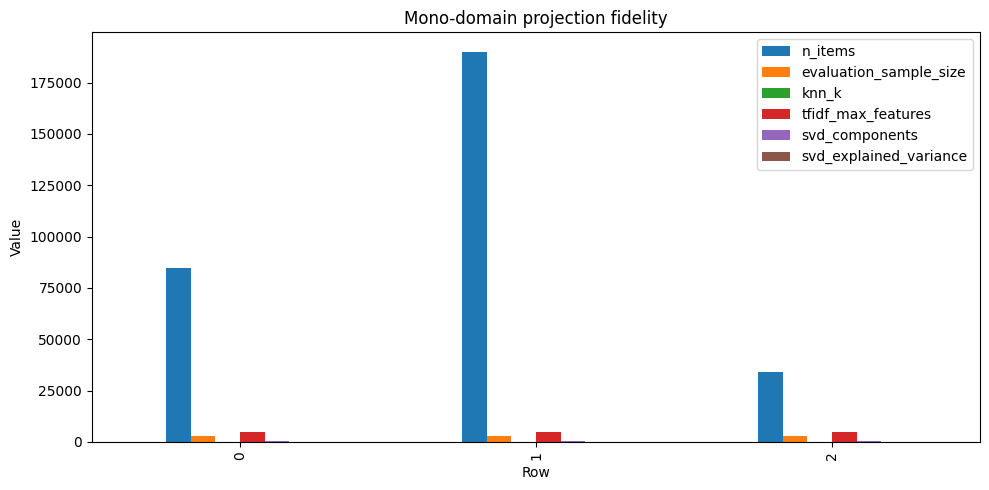

In [10]:
plot_numeric_columns(
    "mono_projection_fidelity",
    title="Mono-domain projection fidelity"
)

### Frozen interpretation from the final run

Approximate trustworthiness values:

| Domain | Trustworthiness |
|---|---:|
| Movies | **0.6976** |
| Music | **0.8216** |
| Restaurants | **0.9566** |

### Interpretation

- **Restaurants:** excellent local preservation.
- **Music:** strong local preservation, although some distortion remains.
- **Movies:** noticeably weaker preservation; fine-grained visual distance should therefore be interpreted more cautiously.

### Defensible conclusion

> The UMAP projection preserves local structure to different degrees across domains. Restaurant and Music maps retain strong local fidelity, while the Movie projection involves greater compression/distortion.

### Limitation

Trustworthiness evaluates preservation of the **model's representation**, not whether that representation corresponds perfectly to human cultural judgement.

# 2. Fusion-weight experiments

The mono-domain pipelines combine two semantic information sources:

- base semantic information such as tags/categories;
- review-derived semantic embeddings.

The fusion-weight experiments test whether changing the relative contribution of these components materially changes evaluation quality.

These are mainly useful as **model-selection evidence**, not as headline final results.

In [11]:
for key in [
    "movie_fusion_weights",
    "music_fusion_weights",
    "restaurant_fusion_weights",
]:
    show_table(key)
    print()

movie_fusion_weights: 7 rows × 7 columns


,review_share,tfidf_share,tfidf_neighbor_similarity,review_neighbor_similarity,tfidf_score_normalized,review_score_normalized,balanced_score
0,0.00,1.00,0.574302,0.639314,0.787151,0.819657,0.803075
1,0.20,0.80,0.572512,0.655578,0.786256,0.827789,0.806488
2,0.35,0.65,0.567355,0.668829,0.783678,0.834415,0.808251
3,0.50,0.50,0.553872,0.686608,0.776936,0.843304,0.808761
4,0.65,0.35,0.520095,0.710686,0.760048,0.855343,0.804884
5,0.80,0.20,0.423223,0.745507,0.711612,0.872753,0.783988
6,1.00,0.00,0.136638,0.777819,0.568319,0.888910,0.693349



music_fusion_weights: 7 rows × 11 columns


,review_share,tfidf_share,tfidf_coherence,review_coherence,balanced_score,evaluation_sample_size,min_reviews,k_neighbors,tfidf_components,review_dimensions,svd_explained_variance
0,0.00,1.00,0.711124,0.448494,0.784447,3000,1,15,256,384,0.629829
1,0.20,0.80,0.708488,0.470786,0.790375,3000,1,15,256,384,0.629829
2,0.35,0.65,0.700718,0.490918,0.794461,3000,1,15,256,384,0.629829
3,0.50,0.50,0.683978,0.513115,0.796990,3000,1,15,256,384,0.629829
4,0.65,0.35,0.650462,0.537268,0.795928,3000,1,15,256,384,0.629829
5,0.80,0.20,0.577478,0.563819,0.785309,3000,1,15,256,384,0.629829
6,1.00,0.00,0.328575,0.588648,0.723509,3000,1,15,256,384,0.629829



restaurant_fusion_weights: 7 rows × 11 columns


,review_share,tfidf_share,tfidf_coherence,review_coherence,balanced_score,evaluation_sample_size,min_reviews,k_neighbors,tfidf_components,review_dimensions,svd_explained_variance
0,0.00,1.00,0.559449,0.877739,0.851928,3000,1,15,256,384,0.427663
1,0.20,0.80,0.558303,0.887716,0.853632,3000,1,15,256,384,0.427663
2,0.35,0.65,0.555404,0.895257,0.854298,3000,1,15,256,384,0.427663
3,0.50,0.50,0.549622,0.902961,0.854105,3000,1,15,256,384,0.427663
4,0.65,0.35,0.538584,0.910949,0.852334,3000,1,15,256,384,0.427663
5,0.80,0.20,0.514848,0.919621,0.846691,3000,1,15,256,384,0.427663
6,1.00,0.00,0.399223,0.928895,0.810955,3000,1,15,256,384,0.427663


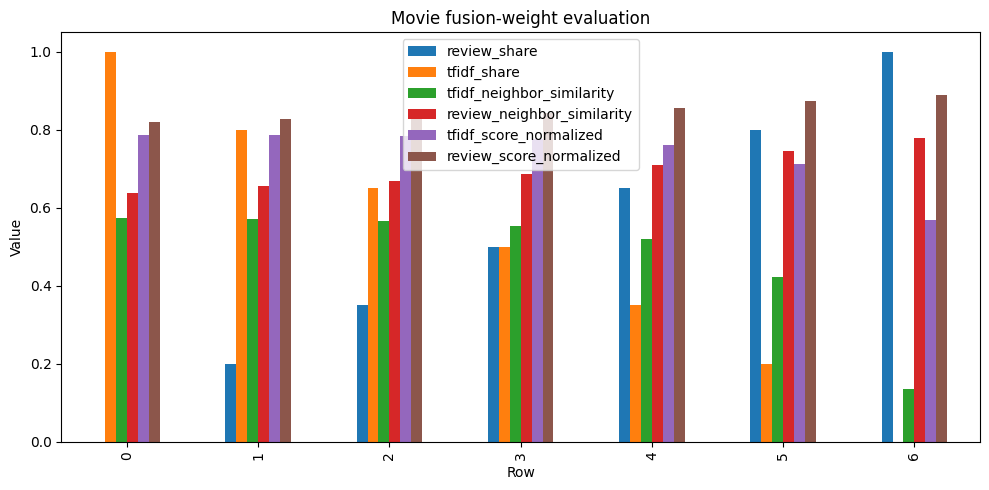

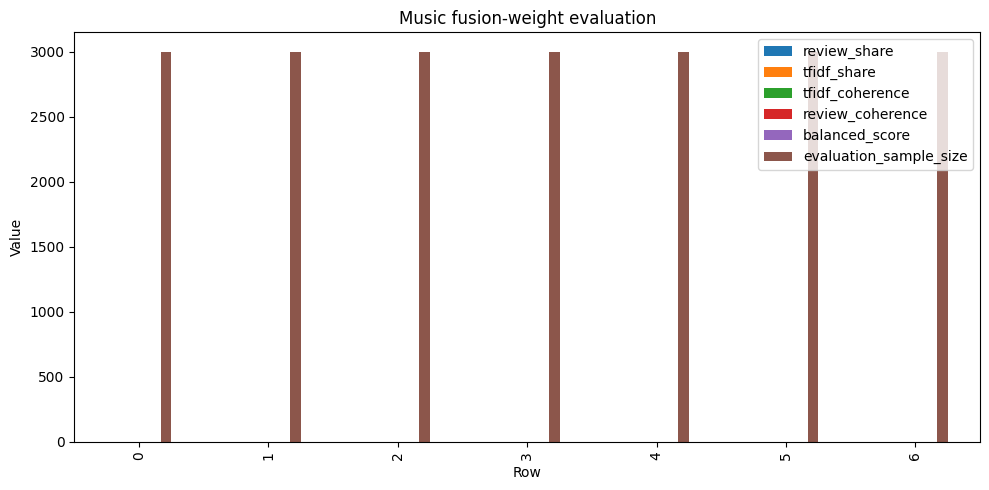

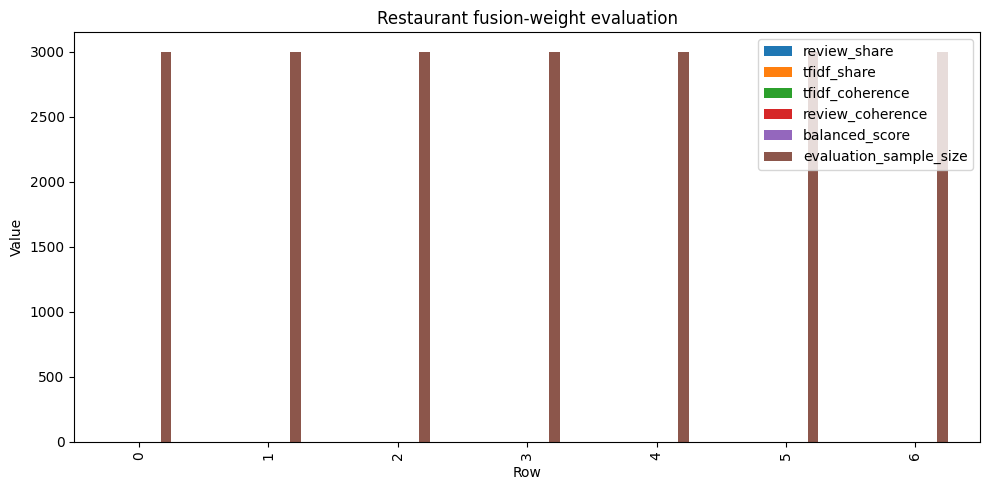

In [12]:
for key, title in [
    ("movie_fusion_weights", "Movie fusion-weight evaluation"),
    ("music_fusion_weights", "Music fusion-weight evaluation"),
    ("restaurant_fusion_weights", "Restaurant fusion-weight evaluation"),
]:
    plot_numeric_columns(key, title=title)

### How to discuss fusion weights

Unless the experiments show a dramatic optimum, use them conservatively:

> The fusion experiment was used to verify that the selected weighting offered a reasonable balance between structured semantic metadata and review-derived semantic information.

Avoid implying that a small difference between neighbouring weights proves a universally optimal parameter.

# 3. Global atlas comparison

These files compare the final atlas variants at a higher level.

They are useful for summarising:

- population size;
- clustering behaviour;
- domain mixing;
- broad structural differences between General Semantic and Feel atlases.

In [13]:
show_table("atlas_metrics_summary")

atlas_metrics_summary: 7 rows × 31 columns


,atlas_id,atlas_label,n_items,n_domains,knn_k,cluster_count,largest_cluster_share,cluster_size_entropy,cluster_silhouette_2d,domain_knn_accuracy_2d,domain_knn_balanced_accuracy_2d,domain_chance_accuracy,local_domain_entropy_2d,cross_domain_neighbor_share_2d,domain_silhouette_2d,cluster_domain_purity,cluster_domain_entropy,review_status_knn_balanced_accuracy_2d,review_status_same_neighbor_share_2d,review_status_silhouette_2d,source_feature_space,source_feature_dimensions,trustworthiness,knn_preservation,projection_sample_size,source_domain_knn_balanced_accuracy,source_local_domain_entropy,source_cross_domain_neighbor_share,source_domain_silhouette,method,source_csv
0,movies,Movies,84432,1,15,110,0.253636,0.663688,0.268286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9870,0.984333,0.461688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mono-domain,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movie_map_v1.csv
1,music,Music,189948,1,15,206,0.206072,0.746985,0.239643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8940,0.863967,0.113164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mono-domain,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\music_map_v1.csv
2,restaurants,Restaurants,33941,1,15,40,0.226452,0.816911,0.379310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mono-domain,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\restaurant_map_v1.csv
3,movies_music,Movies + Music — General Semantic,274380,2,15,333,0.234430,0.752015,0.259823,0.968667,0.968667,0.500000,0.115280,0.051867,0.300967,0.910668,0.306052,0.9740,0.956900,0.364133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Method A,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_atlas...
4,movies_music_restaurants,Movies + Music + Restaurants — General Semantic,308321,3,15,355,0.244421,0.744469,0.235988,0.976667,0.976667,0.333333,0.045903,0.035141,0.448284,0.901187,0.230816,0.9795,0.967800,0.155152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Method A,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_resta...
5,movies_music_feel,Movies + Music — Feel,220062,2,15,12,0.980174,0.054064,0.037689,0.836333,0.836333,0.500000,0.437645,0.216044,0.287892,0.714099,0.861557,0.8510,0.802467,0.343237,13D globally-standardized Feel Space,13.0,0.852503,0.124444,3000.0,0.893000,0.317749,0.148633,0.138485,Method B,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_feel_...
6,movies_music_restaurants_feel,Movies + Music + Restaurants — Feel,254003,3,15,15,0.827360,0.227843,-0.079255,0.894667,0.894667,0.333333,0.194225,0.146474,0.470004,0.750692,0.479177,0.8940,0.849600,0.228464,13D globally-standardized Feel Space,13.0,0.876785,0.151600,3000.0,0.924667,0.143311,0.104622,0.195102,Method B,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_resta...


In [14]:
show_table("cross_domain_comparison")

cross_domain_comparison: 4 rows × 31 columns


,atlas_id,atlas_label,n_items,n_domains,knn_k,cluster_count,largest_cluster_share,cluster_size_entropy,cluster_silhouette_2d,domain_knn_accuracy_2d,domain_knn_balanced_accuracy_2d,domain_chance_accuracy,local_domain_entropy_2d,cross_domain_neighbor_share_2d,domain_silhouette_2d,cluster_domain_purity,cluster_domain_entropy,review_status_knn_balanced_accuracy_2d,review_status_same_neighbor_share_2d,review_status_silhouette_2d,source_feature_space,source_feature_dimensions,trustworthiness,knn_preservation,projection_sample_size,source_domain_knn_balanced_accuracy,source_local_domain_entropy,source_cross_domain_neighbor_share,source_domain_silhouette,method,source_csv
0,movies_music,Movies + Music — General Semantic,274380,2,15,333,0.234430,0.752015,0.259823,0.968667,0.968667,0.500000,0.115280,0.051867,0.300967,0.910668,0.306052,0.9740,0.956900,0.364133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Method A,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_atlas...
1,movies_music_restaurants,Movies + Music + Restaurants — General Semantic,308321,3,15,355,0.244421,0.744469,0.235988,0.976667,0.976667,0.333333,0.045903,0.035141,0.448284,0.901187,0.230816,0.9795,0.967800,0.155152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Method A,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_resta...
2,movies_music_feel,Movies + Music — Feel,220062,2,15,12,0.980174,0.054064,0.037689,0.836333,0.836333,0.500000,0.437645,0.216044,0.287892,0.714099,0.861557,0.8510,0.802467,0.343237,13D globally-standardized Feel Space,13.0,0.852503,0.124444,3000.0,0.893000,0.317749,0.148633,0.138485,Method B,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_feel_...
3,movies_music_restaurants_feel,Movies + Music + Restaurants — Feel,254003,3,15,15,0.827360,0.227843,-0.079255,0.894667,0.894667,0.333333,0.194225,0.146474,0.470004,0.750692,0.479177,0.8940,0.849600,0.228464,13D globally-standardized Feel Space,13.0,0.876785,0.151600,3000.0,0.924667,0.143311,0.104622,0.195102,Method B,C:\Users\antoi\Documents\All_Files\Projects\University\FYP\Semantic_Atlas_Universe\data\processed\movies_music_resta...


## Cluster composition

Cluster-composition tables are descriptive rather than a single quality score.

They answer questions such as:

- Is a region almost entirely one domain?
- Are clusters genuinely cross-domain?
- Does one cluster contain most of the population?
- How fragmented or concentrated is the clustering?

This is especially important for the Feel atlases: a large cluster does **not** automatically mean the representation failed. It can indicate a broad continuous manifold that the clustering algorithm does not naturally partition into many discrete groups.

In [15]:
for key in [
    "composition_movies_music",
    "composition_movies_music_feel",
    "composition_movies_music_restaurants",
    "composition_movies_music_restaurants_feel",
]:
    show_table(key, rows=20)
    print()

composition_movies_music: 333 rows × 8 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music
0,-1,64323,0.714115,0.863347,18389,0.285885,45934,0.714115
1,0,36716,0.917311,0.411583,3036,0.082689,33680,0.917311
2,1,262,0.919847,0.402717,241,0.919847,21,0.080153
3,2,421,0.667458,0.917502,140,0.332542,281,0.667458
4,3,386,1.000000,-0.000000,386,1.000000,0,0.000000
5,4,305,0.803279,0.715322,60,0.196721,245,0.803279
6,5,280,1.000000,-0.000000,280,1.000000,0,0.000000
7,6,157,0.993631,0.055622,156,0.993631,1,0.006369
8,7,404,1.000000,-0.000000,404,1.000000,0,0.000000
9,8,180,1.000000,-0.000000,0,0.000000,180,1.000000



composition_movies_music_feel: 12 rows × 8 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music
0,-1,2045,0.591687,0.975606,835,0.408313,1210,0.591687
1,0,290,0.934483,0.348968,271,0.934483,19,0.065517
2,1,161,0.826087,0.666578,28,0.173913,133,0.826087
3,2,164,0.993902,0.053633,1,0.006098,163,0.993902
4,3,232,0.762931,0.790132,55,0.237069,177,0.762931
5,4,201,0.512438,0.999554,103,0.512438,98,0.487562
6,5,221,0.841629,0.630398,186,0.841629,35,0.158371
7,6,203,0.709360,0.869547,59,0.290640,144,0.709360
8,7,150,0.600000,0.970951,60,0.400000,90,0.600000
9,8,155,0.993548,0.056220,1,0.006452,154,0.993548



composition_movies_music_restaurants: 355 rows × 10 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music,count_restaurants,share_restaurants
0,-1,75360,0.666627,0.730671,20133,0.267158,50237,0.666627,4990,0.066215
1,0,36843,0.916891,0.260600,3062,0.083109,33781,0.916891,0,0.000000
2,1,667,0.847076,0.482573,62,0.092954,40,0.059970,565,0.847076
3,2,243,1.000000,-0.000000,243,1.000000,0,0.000000,0,0.000000
4,3,217,0.995392,0.026752,216,0.995392,1,0.004608,0,0.000000
5,4,572,1.000000,-0.000000,572,1.000000,0,0.000000,0,0.000000
6,5,476,1.000000,-0.000000,476,1.000000,0,0.000000,0,0.000000
7,6,218,1.000000,-0.000000,218,1.000000,0,0.000000,0,0.000000
8,7,203,1.000000,-0.000000,0,0.000000,0,0.000000,203,1.000000
9,8,404,0.933168,0.223341,0,0.000000,27,0.066832,377,0.933168



composition_movies_music_restaurants_feel: 15 rows × 10 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music,count_restaurants,share_restaurants
0,-1,4286,0.633458,0.624479,1547,0.360943,2715,0.633458,24,0.005600
1,0,272,1.000000,-0.000000,272,1.000000,0,0.000000,0,0.000000
2,1,183,0.830601,0.414097,152,0.830601,31,0.169399,0,0.000000
3,2,160,1.000000,-0.000000,0,0.000000,160,1.000000,0,0.000000
4,3,34308,0.986563,0.071391,104,0.003031,357,0.010406,33847,0.986563
5,4,167,0.610778,0.608403,102,0.610778,65,0.389222,0,0.000000
6,5,168,0.636905,0.596369,61,0.363095,107,0.636905,0,0.000000
7,6,307,0.941368,0.203153,18,0.058632,289,0.941368,0,0.000000
8,7,321,0.850467,0.384028,48,0.149533,273,0.850467,0,0.000000
9,8,154,0.564935,0.623232,87,0.564935,67,0.435065,0,0.000000


### Important frozen observation

The Feel atlases showed strong giant-cluster behaviour:

- Movies + Music Feel: largest cluster roughly **98%**.
- Movies + Music + Restaurants Feel: largest cluster roughly **83%**.

This should be reported as a limitation of **discrete cluster interpretation**, not automatically as failure of the continuous atlas.

The frontend therefore gives greater interpretive value to:

- local nearest neighbours;
- continuous Feel profiles;
- individual dimension values;
- map position.

LLM-generated cluster names remain a **post-hoc interface aid**.

# 4. Matched cross-domain evaluation — core Method A vs Method B test

This is arguably the most important direct comparison in the project.

## Why matched populations are necessary

Method A and Method B can contain different numbers of semantically defined entities.

A naive comparison could therefore confuse a **method difference** with a **population difference**.

The matched evaluation restricts both approaches to the **same entities**, making the comparison substantially fairer.

The key question is:

> **When evaluated on the same items, does the Feel representation produce more cross-domain local neighbourhoods than the General Semantic representation?**

In [16]:
show_table("matched_population_summary")

matched_population_summary: 2 rows × 10 columns


,pair_id,pair_label,method_a_full_items,method_b_full_items,matched_items,method_a_only_items,method_b_only_items,matched_movies,matched_music,matched_restaurants
0,movies_music,Movies + Music,274380,220062,220062,54318,0,63324,156738,NaN
1,movies_music_restaurants,Movies + Music + Restaurants,308321,254003,254003,54318,0,63324,156738,33941.0


In [17]:
show_table("matched_atlas_metrics")

matched_atlas_metrics: 4 rows × 32 columns


,atlas_id,atlas_label,n_items,n_domains,knn_k,cluster_count,largest_cluster_share,cluster_size_entropy,cluster_silhouette_2d,domain_knn_accuracy_2d,domain_knn_balanced_accuracy_2d,domain_chance_accuracy,local_domain_entropy_2d,cross_domain_neighbor_share_2d,domain_silhouette_2d,cluster_domain_purity,cluster_domain_entropy,review_status_knn_balanced_accuracy_2d,review_status_same_neighbor_share_2d,review_status_silhouette_2d,source_feature_space,source_feature_dimensions,trustworthiness,knn_preservation,projection_sample_size,source_domain_knn_balanced_accuracy,source_local_domain_entropy,source_cross_domain_neighbor_share,source_domain_silhouette,pair_id,method,population
0,movies_music_method_a_matched,Movies + Music — General Semantic,220062,2,15,333,0.267229,0.782155,0.146623,0.984667,0.984667,0.500000,0.052327,0.021956,0.426337,0.930220,0.256070,0.9745,0.955500,0.414013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,movies_music,Method A,matched
1,movies_music_method_b_matched,Movies + Music — Feel,220062,2,15,12,0.980174,0.054064,0.022450,0.852333,0.852333,0.500000,0.434449,0.206111,0.298960,0.714099,0.861557,0.8625,0.806267,0.342002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,movies_music,Method B,matched
2,movies_music_restaurants_method_a_matched,Movies + Music + Restaurants — General Semantic,254003,3,15,355,0.279064,0.764415,0.150453,0.988444,0.988444,0.333333,0.023689,0.017837,0.570438,0.911521,0.216663,0.9815,0.971400,0.209368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,movies_music_restaurants,Method A,matched
3,movies_music_restaurants_method_b_matched,Movies + Music + Restaurants — Feel,254003,3,15,15,0.827360,0.227843,-0.085997,0.884667,0.884667,0.333333,0.202493,0.157511,0.471653,0.750692,0.479177,0.8935,0.854300,0.227366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,movies_music_restaurants,Method B,matched


In [18]:
show_table("matched_method_comparison")

matched_method_comparison: 2 rows × 25 columns


,pair_id,pair_label,matched_items,method_a_domain_knn_balanced_accuracy,method_b_domain_knn_balanced_accuracy,domain_knn_accuracy_reduction,method_a_local_domain_entropy,method_b_local_domain_entropy,local_domain_entropy_increase,method_a_cross_domain_neighbor_share,method_b_cross_domain_neighbor_share,cross_domain_neighbor_share_increase,method_a_domain_silhouette,method_b_domain_silhouette,domain_silhouette_change,method_a_cluster_count,method_b_cluster_count,method_a_largest_cluster_share,method_b_largest_cluster_share,method_a_cluster_silhouette,method_b_cluster_silhouette,method_a_review_status_knn_accuracy,method_b_review_status_knn_accuracy,method_a_review_status_silhouette,method_b_review_status_silhouette
0,movies_music,Movies + Music,220062,0.984667,0.852333,0.132333,0.052327,0.434449,0.382121,0.021956,0.206111,0.184156,0.426337,0.298960,-0.127378,333,12,0.267229,0.980174,0.146623,0.022450,0.9745,0.8625,0.414013,0.342002
1,movies_music_restaurants,Movies + Music + Restaurants,254003,0.988444,0.884667,0.103778,0.023689,0.202493,0.178803,0.017837,0.157511,0.139674,0.570438,0.471653,-0.098785,355,15,0.279064,0.827360,0.150453,-0.085997,0.9815,0.8935,0.209368,0.227366


### Frozen matched-population result

#### Movies + Music

```text
General Semantic (Method A):  ~0.0220 cross-domain neighbour share
Feel (Method B):              ~0.2061 cross-domain neighbour share
```

Approximately a **9.4× increase**.

#### Movies + Music + Restaurants

```text
General Semantic (Method A):  ~0.0178
Feel (Method B):              ~0.1575
```

Approximately an **8.8× increase**.

### What this means

> **Changing the shared representation changes the nature of cross-domain proximity in a large and measurable way.**

Method A tends to preserve domain-specific/literal semantic structure.

Method B substantially increases the frequency with which local neighbours come from another domain.

### What this does NOT prove

It does **not** prove that Feel similarity is objectively better.

It supports the narrower claim that the experiential representation better achieves the project's design objective of creating cross-domain neighbourhoods based on a shared Feel space.

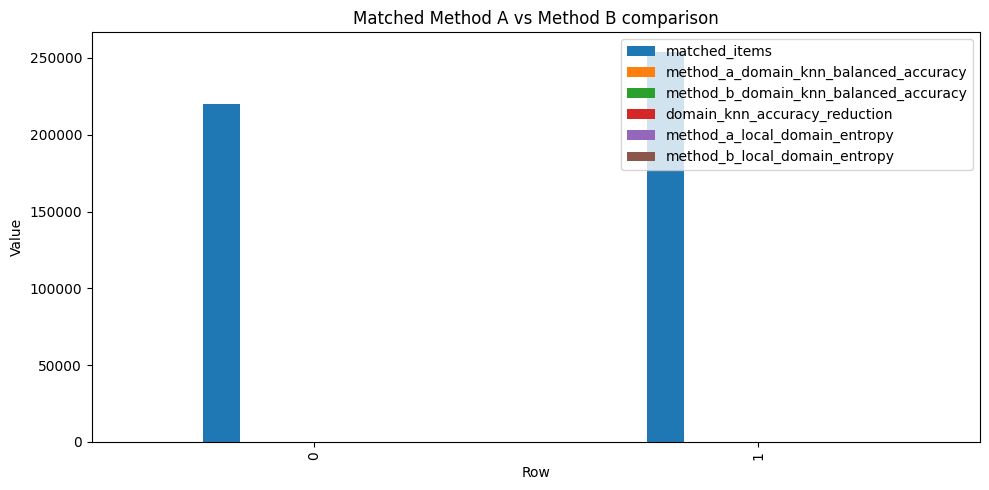

In [19]:
plot_numeric_columns(
    "matched_method_comparison",
    title="Matched Method A vs Method B comparison"
)

## Matched cluster composition

These files show whether the structural differences visible in aggregate metrics also appear at cluster level.

In [20]:
for key in [
    "matched_composition_mm_a",
    "matched_composition_mm_b",
    "matched_composition_mmr_a",
    "matched_composition_mmr_b",
]:
    show_table(key, rows=20)
    print()

matched_composition_mm_a: 333 rows × 8 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music
0,-1,58807,0.781097,0.758158,12873,0.218903,45934,0.781097
1,0,591,0.795262,0.731303,121,0.204738,470,0.795262
2,1,262,0.919847,0.402717,241,0.919847,21,0.080153
3,2,320,0.878125,0.534727,39,0.121875,281,0.878125
4,3,21,1.000000,-0.000000,21,1.000000,0,0.000000
5,4,265,0.924528,0.386019,20,0.075472,245,0.924528
6,5,69,1.000000,-0.000000,69,1.000000,0,0.000000
7,6,7,0.857143,0.591673,6,0.857143,1,0.142857
8,7,16,1.000000,-0.000000,16,1.000000,0,0.000000
9,8,180,1.000000,-0.000000,0,0.000000,180,1.000000



matched_composition_mm_b: 12 rows × 8 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music
0,-1,2045,0.591687,0.975606,835,0.408313,1210,0.591687
1,0,290,0.934483,0.348968,271,0.934483,19,0.065517
2,1,161,0.826087,0.666578,28,0.173913,133,0.826087
3,2,164,0.993902,0.053633,1,0.006098,163,0.993902
4,3,232,0.762931,0.790132,55,0.237069,177,0.762931
5,4,201,0.512438,0.999554,103,0.512438,98,0.487562
6,5,221,0.841629,0.630398,186,0.841629,35,0.158371
7,6,203,0.709360,0.869547,59,0.290640,144,0.709360
8,7,150,0.600000,0.970951,60,0.400000,90,0.600000
9,8,155,0.993548,0.056220,1,0.006452,154,0.993548



matched_composition_mmr_a: 355 rows × 10 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music,count_restaurants,share_restaurants
0,-1,70883,0.708731,0.695753,15656,0.220871,50237,0.708731,4990,0.070398
1,0,718,0.795265,0.461398,147,0.204735,571,0.795265,0,0.000000
2,1,612,0.923203,0.275983,7,0.011438,40,0.065359,565,0.923203
3,2,32,1.000000,-0.000000,32,1.000000,0,0.000000,0,0.000000
4,3,26,0.961538,0.148391,25,0.961538,1,0.038462,0,0.000000
5,4,200,1.000000,-0.000000,200,1.000000,0,0.000000,0,0.000000
6,5,34,1.000000,-0.000000,34,1.000000,0,0.000000,0,0.000000
7,6,218,1.000000,-0.000000,218,1.000000,0,0.000000,0,0.000000
8,7,203,1.000000,-0.000000,0,0.000000,0,0.000000,203,1.000000
9,8,404,0.933168,0.223341,0,0.000000,27,0.066832,377,0.933168



matched_composition_mmr_b: 15 rows × 10 columns


,cluster,cluster_size,domain_purity,domain_entropy,count_movies,share_movies,count_music,share_music,count_restaurants,share_restaurants
0,-1,4286,0.633458,0.624479,1547,0.360943,2715,0.633458,24,0.005600
1,0,272,1.000000,-0.000000,272,1.000000,0,0.000000,0,0.000000
2,1,183,0.830601,0.414097,152,0.830601,31,0.169399,0,0.000000
3,2,160,1.000000,-0.000000,0,0.000000,160,1.000000,0,0.000000
4,3,34308,0.986563,0.071391,104,0.003031,357,0.010406,33847,0.986563
5,4,167,0.610778,0.608403,102,0.610778,65,0.389222,0,0.000000
6,5,168,0.636905,0.596369,61,0.363095,107,0.636905,0,0.000000
7,6,307,0.941368,0.203153,18,0.058632,289,0.941368,0,0.000000
8,7,321,0.850467,0.384028,48,0.149533,273,0.850467,0,0.000000
9,8,154,0.564935,0.623232,87,0.564935,67,0.435065,0,0.000000


# 5. Cross-domain qualitative evaluation

Cross-domain neighbour share tells us **how often** domains mix.

It does not tell us whether the resulting relationships make sense.

The qualitative evaluation therefore inspects concrete query items and their neighbours:

> **When cross-domain neighbours appear, are at least some relationships interpretable in terms of topic, mood, atmosphere, intensity, warmth, nostalgia, etc.?**

In [21]:
show_table("cross_domain_query_summary")

cross_domain_query_summary: 20 rows × 13 columns


,pair_id,pair_label,query_requested,query_domain,query_name,query_source_id,query_entity_key,method_a_neighbors,method_b_neighbors,method_a_b_neighbor_overlap,method_a_b_neighbor_union,method_a_b_neighbor_jaccard,method_b_query_top_feel_traits
0,movies_music,Movies + Music,Toy Story,movies,Toy Story (1995),1,movies:1,5,5,0,10,0.0,energetic (+1.89σ); playful (+1.78σ); grand (+1.20σ); warm (+0.95σ)
1,movies_music,Movies + Music,Titanic,movies,Titanic (1997),1721,movies:1721,5,5,0,10,0.0,serious (-2.34σ); grand (+2.20σ); raw (-1.89σ); negative (-1.74σ)
2,movies_music,Movies + Music,La La Land,movies,La La Land (2016),164909,movies:164909,5,5,0,10,0.0,high wonder (+1.99σ); high tender (+1.85σ); high nostalgic (+1.26σ); grand (+1.15σ)
3,movies_music,Movies + Music,Mad Max Fury Road,movies,Mad Max: Fury Road (2015),122882,movies:122882,5,5,0,10,0.0,grand (+4.16σ); powerful (+2.47σ); cold (-2.02σ); high wonder (+1.84σ)
4,movies_music,Movies + Music,Schindler's List,movies,Schindler's List (1993),527,movies:527,5,5,0,10,0.0,grand (+2.53σ); serious (-2.08σ); raw (-1.61σ); high nostalgic (+1.54σ)
5,movies_music,Movies + Music,Coldplay,music,Coldplay,cc197bad-dc9c-440d-a5b5-d52ba2e14234,music:cc197bad-dc9c-440d-a5b5-d52ba2e14234,5,5,0,10,0.0,cold (-2.19σ); novel (-0.94σ); high tender (+0.76σ); high wonder (+0.66σ)
6,movies_music,Movies + Music,Radiohead,music,Radiohead,a74b1b7f-71a5-4011-9441-d0b5e4122711,music:a74b1b7f-71a5-4011-9441-d0b5e4122711,5,5,0,10,0.0,high nostalgic (+1.52σ); energetic (+1.33σ); cold (-1.27σ); powerful (+0.98σ)
7,movies_music,Movies + Music,Eminem,music,Eminem,b95ce3ff-3d05-4e87-9e01-c97b66af13d4,music:b95ce3ff-3d05-4e87-9e01-c97b66af13d4,5,5,0,10,0.0,powerful (+2.18σ); unsettling (+1.63σ); cold (-1.47σ); familiar (+0.96σ)
8,movies_music,Movies + Music,Metallica,music,Metallica,65f4f0c5-ef9e-490c-aee3-909e7ae6b2ab,music:65f4f0c5-ef9e-490c-aee3-909e7ae6b2ab,5,5,0,10,0.0,cold (-2.16σ); serious (-1.55σ); grand (+1.00σ); negative (-0.97σ)
9,movies_music,Movies + Music,Daft Punk,music,Daft Punk,056e4f3e-d505-4dad-8ec1-d04f521cbb56,music:056e4f3e-d505-4dad-8ec1-d04f521cbb56,5,5,0,10,0.0,novel (-1.54σ); energetic (+1.32σ); unsettling (+1.17σ); complex (+1.14σ)


In [22]:
show_table("cross_domain_neighbor_examples", rows=100)

cross_domain_neighbor_examples: 220 rows × 20 columns


,pair_id,pair_label,method,query_requested,query_domain,query_name,query_source_id,query_entity_key,query_cluster,neighbor_domain,neighbor_rank_within_domain,neighbor_name,neighbor_source_id,neighbor_entity_key,neighbor_cluster,distance_2d,feel_distance_13d,query_top_feel_traits,neighbor_top_feel_traits,shared_feel_traits
0,movies_music,Movies + Music,Method A,Toy Story,movies,Toy Story (1995),1,movies:1,140,music,1,Terry Pratchett,44f85621-f8db-45dd-93de-e9f069d28d7d,music:44f85621-f8db-45dd-93de-e9f069d28d7d,-1,0.850105,NaN,NaN,NaN,NaN
1,movies_music,Movies + Music,Method A,Toy Story,movies,Toy Story (1995),1,movies:1,140,music,2,Harold Arlen,3508f3fd-3b18-493c-a362-376736bb6cde,music:3508f3fd-3b18-493c-a362-376736bb6cde,188,0.911542,NaN,NaN,NaN,NaN
2,movies_music,Movies + Music,Method A,Toy Story,movies,Toy Story (1995),1,movies:1,140,music,3,Kreyol La,8fcccb04-b74a-48af-85b8-8f2b506c5741,music:8fcccb04-b74a-48af-85b8-8f2b506c5741,-1,1.191799,NaN,NaN,NaN,NaN
3,movies_music,Movies + Music,Method A,Toy Story,movies,Toy Story (1995),1,movies:1,140,music,4,Lee Mead,696c9b33-3dfc-4894-8109-d0c5206192a9,music:696c9b33-3dfc-4894-8109-d0c5206192a9,188,1.339184,NaN,NaN,NaN,NaN
4,movies_music,Movies + Music,Method A,Toy Story,movies,Toy Story (1995),1,movies:1,140,music,5,Michael Sullivan,bdc30f07-967f-4e45-884b-be52a942ac54,music:bdc30f07-967f-4e45-884b-be52a942ac54,-1,1.353648,NaN,NaN,NaN,NaN
5,movies_music,Movies + Music,Method B,Toy Story,movies,Toy Story (1995),1,movies:1,10,music,1,Rolando,3a09d601-57cb-44d1-afb7-aebdbce6e7e4,music:3a09d601-57cb-44d1-afb7-aebdbce6e7e4,10,0.014630,2.656718,energetic (+1.89σ); playful (+1.78σ); grand (+1.20σ); warm (+0.95σ),refined (+1.35σ); powerful (+1.34σ); energetic (+1.21σ); grand (+1.19σ),energetic (+1.89σ / +1.21σ); grand (+1.20σ / +1.19σ); playful (+1.78σ / +0.88σ)
6,movies_music,Movies + Music,Method B,Toy Story,movies,Toy Story (1995),1,movies:1,10,music,2,Ruthless & Vorwerk,e0a444bb-c7af-4517-90ba-b1f2fc60307e,music:e0a444bb-c7af-4517-90ba-b1f2fc60307e,10,0.014953,2.679921,energetic (+1.89σ); playful (+1.78σ); grand (+1.20σ); warm (+0.95σ),unsettling (+1.50σ); energetic (+1.02σ); high wonder (+0.86σ); warm (+0.48σ),energetic (+1.89σ / +1.02σ); high wonder (+0.83σ / +0.86σ); unsettling (+0.67σ / +1.50σ)
7,movies_music,Movies + Music,Method B,Toy Story,movies,Toy Story (1995),1,movies:1,10,music,3,Eyes Of The Nightmare Jungle,bb18c597-2bcd-4eb8-9adb-305b5e9a969a,music:bb18c597-2bcd-4eb8-9adb-305b5e9a969a,10,0.021711,3.357195,energetic (+1.89σ); playful (+1.78σ); grand (+1.20σ); warm (+0.95σ),high nostalgic (+1.24σ); refined (+1.20σ); novel (-1.11σ); energetic (+0.75σ),high nostalgic (+0.85σ / +1.24σ); energetic (+1.89σ / +0.75σ); warm (+0.95σ / +0.54σ)
8,movies_music,Movies + Music,Method B,Toy Story,movies,Toy Story (1995),1,movies:1,10,music,4,Yoofs,c729992a-6fd5-4ad5-a790-2a306896815c,music:c729992a-6fd5-4ad5-a790-2a306896815c,10,0.021929,4.150277,energetic (+1.89σ); playful (+1.78σ); grand (+1.20σ); warm (+0.95σ),gentle (-1.93σ); playful (+1.83σ); novel (-1.19σ); energetic (+0.78σ),playful (+1.78σ / +1.83σ); energetic (+1.89σ / +0.78σ); high wonder (+0.83σ / +0.28σ)
9,movies_music,Movies + Music,Method B,Toy Story,movies,Toy Story (1995),1,movies:1,10,music,5,Hannah Peel,53c9c1c9-ac0c-4d0a-8513-b385e247b763,music:53c9c1c9-ac0c-4d0a-8513-b385e247b763,10,0.023716,4.762417,energetic (+1.89σ); playful (+1.78σ); grand (+1.20σ); warm (+0.95σ),novel (-1.40σ); intimate (-1.40σ); gentle (-0.83σ); low wonder (-0.75σ),energetic (+1.89σ / +0.72σ); playful (+1.78σ / +0.52σ); unsettling (+0.67σ / +0.33σ)


### Interpretation

A useful qualitative finding is not:

> “Every recommendation is correct.”

A stronger formulation is:

> Examples demonstrate that the Feel representation can produce interpretable cross-domain analogies that would be difficult to obtain from literal semantic matching alone.

Counterexamples should also be acknowledged where useful.

Imperfect neighbours are expected because:

- the 13 experiential dimensions are an engineered abstraction;
- text embeddings only approximate perceived experience;
- UMAP introduces projection distortion;
- subjective cultural similarity has no single universal ground truth.

# 6. Feel-space representation evaluation

Before trusting the Feel atlas, the 13-dimensional experiential representation itself needs inspection.

The outputs address:

1. Are dimensions numerically well-behaved?
2. Are some dimensions almost duplicates?
3. Do domains occupy systematically different parts of the Feel space?
4. Do high/low extremes correspond to recognisable examples?
5. Are known-item profiles intuitively plausible?

## 6.1 Global dimension summary

In [23]:
show_table("feel_global_dimension_summary")
numeric_summary("feel_global_dimension_summary")

feel_global_dimension_summary: 13 rows × 10 columns


,dimension,count,mean,std,min,q25,median,q75,max,range
0,valence,254003,-0.016816,0.055433,-0.246703,-0.049457,-0.007286,0.023616,0.189181,0.435883
1,activation,254003,0.011306,0.040096,-0.222105,-0.013939,0.014086,0.038759,0.169467,0.391571
2,potency,254003,-0.016620,0.040020,-0.242052,-0.042405,-0.016900,0.010266,0.190814,0.432866
3,tension,254003,0.003281,0.043906,-0.194288,-0.018186,0.010888,0.033080,0.179631,0.373919
4,warmth,254003,-0.003405,0.049447,-0.212973,-0.036680,-0.005062,0.028281,0.177636,0.390609
5,scale,254003,0.025489,0.051624,-0.230232,-0.009027,0.025283,0.058765,0.271448,0.501680
6,tone,254003,0.034073,0.058317,-0.292743,-0.003050,0.041019,0.075458,0.256340,0.549083
7,familiarity,254003,-0.046763,0.043076,-0.296026,-0.073919,-0.044815,-0.018354,0.162528,0.458554
8,refinement,254003,-0.032549,0.060219,-0.253721,-0.073483,-0.025790,0.013138,0.196723,0.450444
9,complexity,254003,0.009535,0.035321,-0.274302,-0.012596,0.011591,0.033876,0.196206,0.470508


,count,mean,std,min,25%,50%,75%,max
count,13.0,254003.000000,0.000000,254003.000000,254003.000000,254003.000000,254003.000000,254003.000000
mean,13.0,0.022627,0.054266,-0.046763,-0.016620,0.009535,0.034073,0.128331
std,13.0,0.052275,0.011511,0.035321,0.043076,0.051624,0.060219,0.072679
min,13.0,-0.226303,0.048927,-0.296026,-0.253721,-0.230232,-0.194288,-0.138926
q25,13.0,-0.010722,0.048867,-0.073919,-0.042405,-0.013939,-0.003050,0.081203
median,13.0,0.024518,0.051451,-0.044815,-0.007286,0.011591,0.041019,0.124176
q75,13.0,0.057077,0.057212,-0.018354,0.023616,0.033876,0.075458,0.170332
max,13.0,0.286218,0.169551,0.162528,0.179631,0.196206,0.271448,0.613260
range,13.0,0.512521,0.137346,0.373919,0.432866,0.458554,0.549083,0.793976


## 6.2 Correlation between Feel dimensions

Correlation is used as a **redundancy diagnostic**.

Very high absolute correlation suggests two dimensions may capture overlapping information.

Moderate correlation is not inherently problematic: experiential concepts naturally overlap.

The 13 dimensions should be described as **engineered semantic axes**, not statistically independent psychological factors.

In [24]:
show_table("feel_high_correlations")

feel_high_correlations: 0 rows × 4 columns


,dimension_a,dimension_b,correlation,absolute_correlation


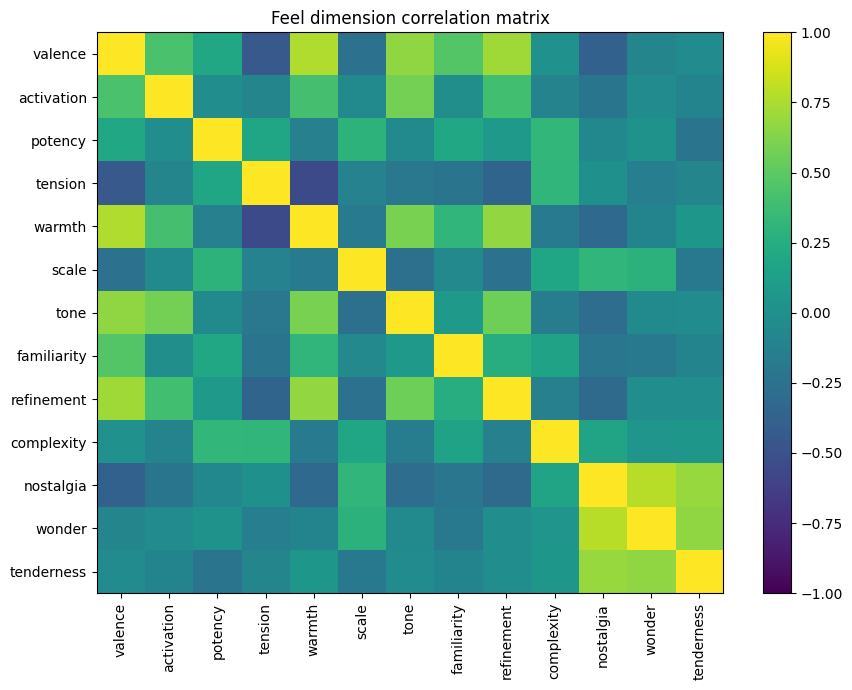

In [25]:
if "feel_correlation_matrix" in tables:
    corr_df = tables["feel_correlation_matrix"].copy()

    if len(corr_df.columns) > 1 and not pd.api.types.is_numeric_dtype(corr_df.iloc[:, 0]):
        corr_df = corr_df.set_index(corr_df.columns[0])

    numeric_corr = corr_df.apply(pd.to_numeric, errors="coerce")

    fig, ax = plt.subplots(figsize=(9, 7))
    image = ax.imshow(numeric_corr.values, aspect="auto", vmin=-1, vmax=1)
    ax.set_title("Feel dimension correlation matrix")
    ax.set_xticks(range(len(numeric_corr.columns)))
    ax.set_xticklabels(numeric_corr.columns, rotation=90)
    ax.set_yticks(range(len(numeric_corr.index)))
    ax.set_yticklabels(numeric_corr.index)
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("[Missing] feel_correlation_matrix")

## 6.3 Domain summaries and domain effects

These outputs investigate whether Movies, Music and Restaurants receive systematically different Feel profiles.

A domain effect does not invalidate cross-domain comparison, but it means the report should avoid claiming complete domain invariance.

> Shared dimensionality should not be confused with identical domain distributions.

In [26]:
show_table("feel_domain_dimension_summary")

feel_domain_dimension_summary: 39 rows × 10 columns


,domain,dimension,count,mean,std,min,q25,median,q75,max
0,movies,valence,63324,-0.076131,0.053049,-0.246703,-0.112587,-0.077245,-0.040592,0.189181
1,movies,activation,63324,-0.012491,0.043091,-0.215554,-0.041410,-0.012337,0.016895,0.161990
2,movies,potency,63324,-0.025745,0.049511,-0.242052,-0.058196,-0.024869,0.007739,0.190721
3,movies,tension,63324,0.021132,0.035120,-0.179371,-0.000614,0.021950,0.043886,0.179631
4,movies,warmth,63324,-0.043165,0.042707,-0.212973,-0.072643,-0.044435,-0.015752,0.157892
5,movies,scale,63324,0.057093,0.060259,-0.230232,0.019022,0.061683,0.098979,0.271448
6,movies,tone,63324,-0.013230,0.057730,-0.292743,-0.052470,-0.014543,0.024254,0.256340
7,movies,familiarity,63324,-0.066597,0.046108,-0.296026,-0.099595,-0.068463,-0.036362,0.132140
8,movies,refinement,63324,-0.095485,0.051617,-0.253721,-0.133014,-0.100413,-0.062841,0.196723
9,movies,complexity,63324,0.013720,0.033454,-0.153649,-0.008106,0.014484,0.035820,0.196206


In [27]:
show_table("feel_domain_effects")

feel_domain_effects: 13 rows × 8 columns


,dimension,eta_squared,domain_mean_range,global_std,standardized_mean_range,mean_movies,mean_music,mean_restaurants
0,tension,0.506394,0.096951,0.043906,2.208145,0.021132,0.013198,-0.075819
1,warmth,0.456850,0.113311,0.049447,2.291561,-0.043165,-0.003269,0.070146
2,refinement,0.440702,0.125539,0.060219,2.084705,-0.095485,-0.020678,0.030054
3,valence,0.416211,0.105091,0.055433,1.895817,-0.076131,-0.002765,0.028960
4,tone,0.265370,0.094327,0.058317,1.617475,-0.013230,0.043001,0.081097
5,scale,0.206622,0.050048,0.051624,0.969457,0.057093,0.007046,0.051692
6,complexity,0.180209,0.044652,0.035321,1.264206,0.013720,0.016094,-0.028559
7,nostalgia,0.135824,0.063005,0.072679,0.866892,0.174600,0.111595,0.119297
8,activation,0.131441,0.043660,0.040096,1.088870,-0.012491,0.016619,0.031169
9,potency,0.096916,0.034080,0.040020,0.851565,-0.025745,-0.007524,-0.041603


In [28]:
show_table("feel_modality_summary")

feel_modality_summary: 12 rows × 4 columns


,domain,semantic_source,count,percentage
0,movies,base_and_reviews,27611,32.702056
1,movies,base_only,20559,24.349773
2,movies,review_only,15154,17.948171
3,movies,neither,21108,25.000000
4,music,base_and_reviews,5072,2.670204
5,music,base_only,151607,79.815002
6,music,review_only,59,0.031061
7,music,neither,33210,17.483732
8,restaurants,base_and_reviews,33941,100.000000
9,restaurants,base_only,0,0.000000


The matched cross-domain neighbour experiment remains especially important because it tests the **practical consequence** of the representation—actual local domain mixing—rather than assuming comparability from the dimensions alone.

## 6.4 Dimension extremes

Extreme examples provide an intuitive sanity check.

If items at the positive/negative ends of dimensions such as valence, activation, tension, warmth, nostalgia, wonder and tenderness broadly resemble those concepts, this supports **construct interpretability**.

This remains qualitative evidence, not formal psychological validation.

In [29]:
show_table("feel_dimension_extremes")

feel_dimension_extremes: 130 rows × 11 columns


,dimension,direction,rank,score,domain,source_id,id,semantic_source,has_base_semantics,has_review_semantics,reviews_used_for_embedding
0,valence,lowest,1,-0.246703,movies,183521,movies:183521,base_and_reviews,True,True,16
1,valence,lowest,2,-0.245805,movies,248158,movies:248158,review_only,False,True,22
2,valence,lowest,3,-0.240199,movies,183785,movies:183785,base_and_reviews,True,True,21
3,valence,lowest,4,-0.239978,movies,206855,movies:206855,review_only,False,True,21
4,valence,lowest,5,-0.236363,movies,225087,movies:225087,review_only,False,True,39
...,...,...,...,...,...,...,...,...,...,...,...
125,tenderness,highest,1,0.613260,movies,182781,movies:182781,base_only,True,False,0
126,tenderness,highest,2,0.581121,movies,148298,movies:148298,base_only,True,False,0
127,tenderness,highest,3,0.572445,movies,41094,movies:41094,base_only,True,False,0
128,tenderness,highest,4,0.572445,movies,194835,movies:194835,base_only,True,False,0


In [30]:
show_table("feel_dimension_extremes_named")

feel_dimension_extremes_named: 520 rows × 14 columns


,scope,dimension,direction,semantic_interpretation,rank,score,domain,source_id,id,display_name,semantic_source,has_base_semantics,has_review_semantics,reviews_used_for_embedding
0,all_domains,valence,lowest,negative,1,-0.246703,movies,183521,movies:183521,Don't Sleep (2017),base_and_reviews,True,True,16
1,all_domains,valence,lowest,negative,2,-0.245805,movies,248158,movies:248158,Basement (2010),review_only,False,True,22
2,all_domains,valence,lowest,negative,3,-0.240199,movies,183785,movies:183785,Monday at 11:01 A.M. (2016),base_and_reviews,True,True,21
3,all_domains,valence,lowest,negative,4,-0.239978,movies,206855,movies:206855,Don't Look (2018),review_only,False,True,21
4,all_domains,valence,lowest,negative,5,-0.236363,movies,225087,movies:225087,Grim (1995),review_only,False,True,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,restaurants,tenderness,highest,high_tender,1,0.295023,restaurants,XTVlIRK2X9XYGCv-1OiaFw,restaurants:XTVlIRK2X9XYGCv-1OiaFw,King and Queen Massage & Spa,base_and_reviews,True,True,47
516,restaurants,tenderness,highest,high_tender,2,0.286771,restaurants,rvF-BwyaCHeb30u3Xf7FbQ,restaurants:rvF-BwyaCHeb30u3Xf7FbQ,The Elysian Bar,base_and_reviews,True,True,50
517,restaurants,tenderness,highest,high_tender,3,0.285797,restaurants,R32_LaNcLXyS2-dtrcuBGw,restaurants:R32_LaNcLXyS2-dtrcuBGw,Roghani’s Restaurant,base_and_reviews,True,True,29
518,restaurants,tenderness,highest,high_tender,4,0.283356,restaurants,2MAQeAqmD8enCT2ZYqUgIQ,restaurants:2MAQeAqmD8enCT2ZYqUgIQ,The Melting Pot - Nashville,base_and_reviews,True,True,50


## 6.5 Known-item profiles

In [31]:
show_table("feel_known_item_profiles")

feel_known_item_profiles: 20 rows × 22 columns


,requested_name,domain,source_id,display_name,is_semantically_defined,semantic_source,has_base_semantics,has_review_semantics,reviews_used_for_embedding,valence,activation,potency,tension,warmth,scale,tone,familiarity,refinement,complexity,nostalgia,wonder,tenderness
0,Toy Story,movies,1,Toy Story (1995),True,base_and_reviews,True,True,50,0.014826,0.086086,0.012363,0.036866,0.024770,0.085630,0.130205,-0.018675,-0.053432,0.031524,0.194242,0.151846,0.104216
1,The Dark Knight,movies,130219,The Dark Knight (2011),False,neither,False,False,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Titanic,movies,1721,Titanic (1997),True,base_and_reviews,True,True,50,-0.119319,0.004193,0.020676,0.010700,-0.083499,0.138916,-0.109195,-0.097867,-0.151922,-0.001154,0.218657,0.161516,0.143445
3,The Shining,movies,180263,The Shining (1997),True,base_and_reviews,True,True,50,-0.151546,-0.026422,-0.037128,0.025545,-0.078831,0.092506,-0.071368,-0.093718,-0.147208,-0.048936,0.215253,0.174014,0.126852
4,La La Land,movies,164909,La La Land (2016),True,base_and_reviews,True,True,50,-0.015506,0.034529,-0.017070,0.011191,0.000025,0.082999,-0.014296,-0.096733,-0.075066,0.039662,0.225822,0.232106,0.222680
5,Mad Max Fury Road,movies,122882,Mad Max: Fury Road (2015),True,base_and_reviews,True,True,50,-0.112099,-0.023851,0.088449,0.028815,-0.098747,0.243250,-0.063131,-0.117704,-0.132489,0.026456,0.231537,0.221570,0.088169
6,Schindler's List,movies,527,Schindler's List (1993),True,base_and_reviews,True,True,50,-0.080311,-0.049569,0.025591,0.030389,-0.067522,0.156378,-0.094405,-0.052533,-0.136037,0.049353,0.247290,0.190730,0.093288
7,Coldplay,music,cc197bad-dc9c-440d-a5b5-d52ba2e14234,Coldplay,True,base_and_reviews,True,True,4,-0.043935,0.018717,-0.017078,0.005058,-0.105839,-0.002612,0.042784,-0.090565,-0.057393,-0.001770,0.165856,0.140170,0.151514
8,Radiohead,music,a74b1b7f-71a5-4011-9441-d0b5e4122711,Radiohead,True,base_and_reviews,True,True,11,-0.020917,0.062965,0.027263,0.029990,-0.067483,0.059510,0.053706,-0.082438,-0.016457,0.012822,0.245607,0.157828,0.119626
9,Eminem,music,b95ce3ff-3d05-4e87-9e01-c97b66af13d4,Eminem,True,base_and_reviews,True,True,9,-0.020875,-0.024526,0.076303,0.067874,-0.075987,0.032456,0.014044,-0.003998,-0.094307,0.043318,0.124444,0.049786,0.069764


In [32]:
show_table("feel_name_resolution_summary")

feel_name_resolution_summary: 3 rows × 5 columns


,domain,entities,names_resolved,names_missing,resolution_pct
0,movies,84432,84432,0,100.000000
1,music,189948,189944,4,99.997894
2,restaurants,33941,33941,0,100.000000


Known-item profiles are useful explanatory examples:

> “Does the generated profile broadly align with how the item can reasonably be characterised?”

They are not formal accuracy tests because no authoritative 13-dimensional ground-truth labels exist.

# 7. Overall results synthesis

## Strongest supported conclusions

### A. Mono-domain atlases contain meaningful local semantic structure

Neighbourhood lift is above baseline for all three domains:

- Movies: meaningful genre enrichment;
- Music: particularly strong tag enrichment;
- Restaurants: clear category enrichment.

### B. 2D projection quality varies by domain

Trustworthiness indicates:

- Restaurant 2D structure is highly faithful;
- Music is strongly preserved;
- Movies have substantially more projection distortion.

### C. General Semantic and Feel methods solve different problems

Method A:

> **literal / topical semantic organisation**

Method B:

> **shared experiential organisation**

Neither should be declared universally superior.

### D. Feel substantially increases cross-domain local mixing

Matched comparisons show approximately:

- **9.4×** greater cross-domain neighbour share for Movies + Music;
- **8.8×** greater cross-domain neighbour share for Movies + Music + Restaurants.

### E. Cross-domain Feel similarity is interpretable but not universal

Qualitative examples support interpretable experiential analogies across domains, while subjective similarity remains imperfect and context-dependent.

### F. Feel clustering is a weak summary of a continuous space

Giant-cluster behaviour means discrete cluster labels should not be the primary explanatory mechanism for Feel.

Local neighbours and continuous profiles are stronger interpretive tools.

# 8. What the project does **not** establish

The project does **not** demonstrate that:

1. 2D Euclidean distance is a perfect measure of cultural similarity.
2. UMAP preserves all global relationships from the original embedding.
3. The 13 Feel dimensions are psychologically independent or experimentally validated.
4. Cross-domain Feel neighbours represent a universal human notion of similarity.
5. Cluster membership is a ground-truth cultural taxonomy.
6. LLM-generated cluster names validate the clusters scientifically.
7. One representation is globally “better” than the other.

Instead, the project demonstrates that different engineered representations generate **measurably different, interpretable structures** that can be explored through an interactive research tool.

# 9. Final report-ready interpretation

> The project demonstrates that large heterogeneous cultural datasets can be transformed into interactive semantic atlases whose local organisation is quantitatively measurable and qualitatively interpretable. Mono-domain evaluations show meaningful semantic neighbourhood enrichment, while trustworthiness analysis reveals domain-dependent distortion introduced by 2D projection. In cross-domain experiments, a shared literal semantic representation largely preserves domain separation, whereas the engineered experiential representation produces substantially higher cross-domain neighbour mixing on matched populations. This suggests that cross-domain cultural proximity is strongly dependent on the representation used: literal semantics and shared experiential character expose different forms of similarity. The resulting atlases should therefore be treated as exploratory representations rather than objective cultural taxonomies, with local neighbourhoods and continuous profiles providing stronger evidence than discrete cluster assignments alone.

# 10. Quick results checklist for report writing

Before finalising the Results chapter, verify each item directly against the loaded CSVs.

### Mono-domain

- [ ] Movie semantic lift quoted correctly
- [ ] Movie macro-genre lift quoted correctly
- [ ] Music tag lift quoted correctly
- [ ] Restaurant category lift quoted correctly
- [ ] Movie trustworthiness quoted correctly
- [ ] Music trustworthiness quoted correctly
- [ ] Restaurant trustworthiness quoted correctly

### Cross-domain

- [ ] Matched population sizes reported
- [ ] Method A cross-domain neighbour share reported
- [ ] Method B cross-domain neighbour share reported
- [ ] Relative increase calculated correctly
- [ ] General Semantic vs Feel distinction explained without saying one is universally better

### Feel representation

- [ ] Strong/high dimension correlations acknowledged if relevant
- [ ] Domain effects acknowledged
- [ ] Dimension extremes used as qualitative sanity checks
- [ ] Feel dimensions described as engineered computational descriptors

### Clustering / frontend

- [ ] Giant Feel clusters reported honestly
- [ ] Cluster names described as post-hoc interpretation only
- [ ] 2D nearest-neighbour functionality distinguished from original high-dimensional similarity
- [ ] Limitations of subjective evaluation explicitly discussed

In [33]:
summary_rows = []

for key, df in tables.items():
    summary_rows.append({
        "table": key,
        "rows": len(df),
        "columns": len(df.columns),
        "numeric_columns": len(df.select_dtypes(include=np.number).columns),
    })

result_inventory = (
    pd.DataFrame(summary_rows)
    .sort_values("table")
    .reset_index(drop=True)
)

display(result_inventory)

,table,rows,columns,numeric_columns
0,atlas_metrics_summary,7,31,26
1,composition_movies_music,333,8,8
2,composition_movies_music_feel,12,8,8
3,composition_movies_music_restaurants,355,10,10
4,composition_movies_music_restaurants_feel,15,10,10
5,cross_domain_comparison,4,31,26
6,cross_domain_neighbor_examples,220,20,5
7,cross_domain_query_summary,20,13,5
8,feel_correlation_matrix,13,14,13
9,feel_dimension_extremes,130,11,3


---

## End of evaluation summary

At this point the evaluation stage should be considered **frozen**.

If a number in the report needs checking, return to the corresponding CSV/table in this notebook rather than rerunning the modelling pipeline unless an actual error is discovered.